<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/Sign_Language_(MNIST)_DDMLP_%2B_Conv2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### This Notebook is part of Kaggle's Sign Language (MNIST) competition.

### I applied a simple Deep Dumb MLP and also a Conv2D NN.


**Context**

The Sign Language MNIST is presented here and follows the same CSV format with labels and pixel values in single rows. The American Sign Language letter database of hand gestures represent a multi-class problem with 24 classes of letters (excluding J and Z which require motion).

**Content**

The dataset format is patterned to match closely with the classic MNIST. Each training and test case represents a label (0-25) as a one-to-one map for each alphabetic letter A-Z (and no cases for 9=J or 25=Z because of gesture motions). The training data (27,455 cases) and test data (7172 cases) are approximately half the size of the standard MNIST but otherwise similar with a header row of label, pixel1,pixel2….pixel784 which represent a single 28x28 pixel image with grayscale values between 0-255. The original hand gesture image data represented multiple users repeating the gesture against different backgrounds. The Sign Language MNIST data came from greatly extending the small number (1704) of the color images included as not cropped around the hand region of interest. To create new data, an image pipeline was used based on ImageMagick and included cropping to hands-only, gray-scaling, resizing, and then creating at least 50+ variations to enlarge the quantity. The modification and expansion strategy was filters ('Mitchell', 'Robidoux', 'Catrom', 'Spline', 'Hermite'), along with 5% random pixelation, +/- 15% brightness/contrast, and finally 3 degrees rotation. Because of the tiny size of the images, these modifications effectively alter the resolution and class separation in interesting, controllable ways.

More info can be found here: https://www.kaggle.com/datamunge/sign-language-mnist

### Download data

In [6]:
# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))
  
# # Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


### Set-up

In [3]:
import tensorflow as tf
import tensorflow.keras as keras
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from os import path, getcwd, chdir

In [9]:
%cd '/content/drive/MyDrive/Colab Notebooks/Data/Sign Language MNIST'

/content/drive/MyDrive/Colab Notebooks/Data/Sign Language MNIST


In [10]:
!ls

sign_mnist_test.csv  sign_mnist_train.csv


In [ ]:
# !unzip fashion-mnist_test.csv.zip
# !unzip fashion-mnist_train.csv.zip

Archive:  fashion-mnist_test.csv.zip
replace fashion-mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_test.csv  
Archive:  fashion-mnist_train.csv.zip
replace fashion-mnist_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_train.csv  


In [42]:
df_train_full = pd.read_csv('sign_mnist_train.csv',header=0,sep=',')

print(df_train_full.shape)
df_train_full.head(3)

(27455, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,...,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,...,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,...,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195


In [12]:
df_test = pd.read_csv('sign_mnist_test.csv',header=0,sep=',')
print(df_test.shape)
df_test.head(3)

(7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,152,152,152,152,152,153,153,151,152,152,153,152,152,151,151,150,150,150,149,150,150,150,152,152,151,152,152,152,152,152,...,131,134,144,147,125,87,87,103,107,110,116,113,75,74,74,74,76,74,82,134,168,155,146,137,145,146,149,135,124,125,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,138,137,137,138,138,139,137,142,140,138,139,137,137,136,135,134,133,134,132,129,132,134,135,135,137,139,139,139,140,141,...,114,112,89,48,133,194,182,185,184,184,182,181,172,174,177,178,178,179,181,183,187,175,165,154,118,107,100,75,96,83,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,152,157,163,168,171,182,172,175,185,183,184,185,185,185,183,183,182,181,178,86,88,93,96,108,125,137,145,149,154,160,...,145,123,78,162,239,227,229,226,226,225,224,222,89,91,94,111,136,154,167,184,125,3,166,225,195,188,172,185,161,122,68,166,242,227,230,227,226,225,224,222


In [13]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

df_train_full = reduce_mem_usage(df_train_full)
df_test = reduce_mem_usage(df_test)

Memory usage after optimization is: 41.08 MB
Decreased by 75.0%
Memory usage after optimization is: 10.73 MB
Decreased by 75.0%


In [14]:
df_train = df_train_full.sample(frac=0.7, random_state=0)
df_valid = df_train_full.drop(df_train.index)

In [66]:
X_train, X_valid, X_test = df_train.drop('label',axis=1), df_valid.drop('label',axis=1), df_test.drop('label',axis=1)

y_train, y_valid, y_test = df_train['label'], df_valid['label'], df_test['label']

print(f'X_train shape: {X_train.shape}, X_valid shape: {X_valid.shape}')

X_train shape: (19218, 784), X_valid shape: (8237, 784)


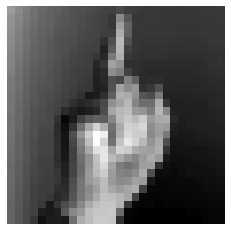

In [52]:
# some_item = X_train.values[1]
# some_item = df_train.iloc[:,1:].values[0]
some_item = df_train_full.iloc[:,1:].values[0]
some_item_image = some_item.reshape(28,28)

plt.imshow(some_item_image, cmap='binary')
plt.axis('off')
plt.show()

Feature creation and standarization



In [67]:
X_train, X_valid, X_test = X_train / 255.0, X_valid / 255.0, X_test / 255.0

In [68]:
## Note: J and Z are not present in the dataset, cf Introduction, so we have 24 unique classes
## => However it's very important to define 26 classes in our last Dense layer because the model will infer 25 classes (0 to 24, even though 9 is missing) so we need at least 25, so 26 is also ok

class_names = [ "A", "B", "C", "D", "E", "F", 
               "G", "H", "I", "K", "L", "M",
               "N","O","P","Q","R","S",
               "T","U","V","W","X","Y"]

#Example:
print("Total classes: ", len(class_names))
print("Example: ",class_names[y_train[0]])

Total classes:  24
Example:  D


In [38]:
X_train.shape

(19218, 28, 28, 1)

In [39]:
y_train

11238    15
11774     0
19202    15
19466     6
24394     0
         ..
13746    19
26160     1
18545     2
27244    19
22397    13
Name: label, Length: 19218, dtype: int8

Simple Sequential NN model

Epoch 1/25
1202/1202 - 7s - loss: 1.2736 - accuracy: 0.6178 - val_loss: 4.3430 - val_accuracy: 0.2923
Epoch 2/25
1202/1202 - 6s - loss: 0.8881 - accuracy: 0.7141 - val_loss: 1.4716 - val_accuracy: 0.5764
Epoch 3/25
1202/1202 - 6s - loss: 0.8127 - accuracy: 0.7287 - val_loss: 1.3839 - val_accuracy: 0.5835
Epoch 4/25
1202/1202 - 6s - loss: 0.7467 - accuracy: 0.7491 - val_loss: 1.5278 - val_accuracy: 0.5585
Epoch 5/25
1202/1202 - 6s - loss: 0.9059 - accuracy: 0.6917 - val_loss: 1.2259 - val_accuracy: 0.6121
Epoch 6/25
1202/1202 - 6s - loss: 0.8913 - accuracy: 0.6931 - val_loss: 1.9080 - val_accuracy: 0.5145
Epoch 7/25
1202/1202 - 6s - loss: 0.8114 - accuracy: 0.7231 - val_loss: 0.9732 - val_accuracy: 0.6671
Epoch 8/25
1202/1202 - 6s - loss: 0.7413 - accuracy: 0.7423 - val_loss: 1.0631 - val_accuracy: 0.6403
Epoch 9/25
1202/1202 - 6s - loss: 0.7210 - accuracy: 0.7535 - val_loss: 3.8882 - val_accuracy: 0.3169
Epoch 10/25
1202/1202 - 6s - loss: 0.6578 - accuracy: 0.7670 - val_loss: 1.2838 - 

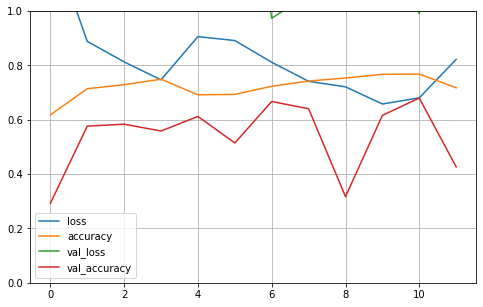

In [69]:
class MyCallBack(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.99):
            print("\nReached 99% accuracy so cancelling training!")
            self.model.stop_training = True

callback = MyCallBack()

input_dim = X_train.shape[1] # (28,28,1)
nb_classes = len(y_train.unique()) #24 
## Note: J and Z are not present in the dataset, cf Introduction, so we have 24 unique classes
## => However it's very important to define 26 classes in our last Dense layer because the model will infer 25 classes (0 to 24, even though 9 is missing) so we need at least 25, so 26 is also ok

model = keras.models.Sequential([
                                 keras.layers.Dense(300, activation='relu',input_dim=input_dim),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.05),
                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.05),
                                 keras.layers.Dense(26, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(X_train,y_train,
          epochs=25,validation_data=(X_valid,y_valid),
          batch_size=16,
          callbacks=[early_stopping],
          verbose=2)

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [70]:
from sklearn.metrics import accuracy_score
preds = np.argmax(model.predict(X_test), axis=-1)

print('Accuracy in Test: {}'.format(accuracy_score(y_test, preds)))

Accuracy in Test: 0.4350250976017847


## Convolutional NN

In [71]:
X_train = X_train.values.reshape(X_train.shape[0], 28, 28, 1)
X_valid = X_valid.values.reshape(X_valid.shape[0], 28, 28, 1)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28, 1)

In [60]:
X_valid.shape

(8237, 28, 28, 1)

In [72]:
from keras.preprocessing.image import ImageDataGenerator

batch_size=32
# Data Augmentation will be counterproductive for this problem
# gen = ImageDataGenerator(rotation_range=40, width_shift_range=0.2, shear_range=0.2,
#                                height_shift_range=0.2, zoom_range=0.2, fill_mode='nearest',
#                          horizontal_flip=True)

gen = ImageDataGenerator()

batches = gen.flow(X_train, y_train, batch_size=batch_size)
val_batches = gen.flow(X_valid, y_valid, batch_size=batch_size)

steps_train = int(X_train.shape[0]/batch_size)
steps_valid = int(X_valid.shape[0]/batch_size)

Epoch 1/25
600/600 - 5s - loss: 1.2239 - accuracy: 0.6412 - val_loss: 0.2331 - val_accuracy: 0.9391
Epoch 2/25
600/600 - 4s - loss: 0.1028 - accuracy: 0.9748 - val_loss: 0.0239 - val_accuracy: 0.9989
Epoch 3/25
600/600 - 4s - loss: 0.0161 - accuracy: 0.9983 - val_loss: 0.0082 - val_accuracy: 0.9996
Epoch 4/25
600/600 - 4s - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0021 - val_accuracy: 1.0000
Epoch 5/25
600/600 - 4s - loss: 0.0014 - accuracy: 1.0000 - val_loss: 0.0018 - val_accuracy: 1.0000
Epoch 6/25
600/600 - 4s - loss: 7.7840e-04 - accuracy: 1.0000 - val_loss: 8.8726e-04 - val_accuracy: 1.0000
Epoch 7/25
600/600 - 4s - loss: 0.0621 - accuracy: 0.9817 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 8/25
600/600 - 4s - loss: 0.0012 - accuracy: 0.9998 - val_loss: 5.6158e-04 - val_accuracy: 1.0000
Epoch 9/25
600/600 - 4s - loss: 3.1230e-04 - accuracy: 1.0000 - val_loss: 3.1400e-04 - val_accuracy: 1.0000
Epoch 10/25
600/600 - 4s - loss: 2.0215e-04 - accuracy: 1.0000 - val_loss: 2.288

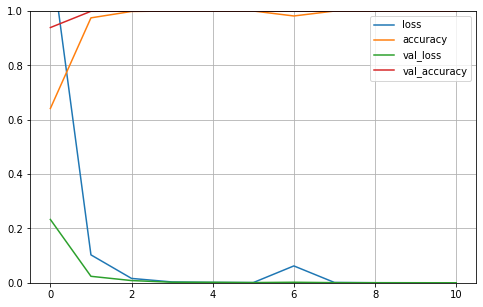

In [73]:
class MyCallBack(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.99):
            print("\nReached 99% accuracy so cancelling training!")
            self.model.stop_training = True

callback = MyCallBack()

input_dim = X_train.shape[1:]
nb_classes = len(y_train.unique())

#This model will only yield 70% accuracy as it has an overcapacity, it's better a simpler one
# model = keras.models.Sequential([
#                                  keras.layers.Conv2D(16,(3,3),activation='relu', input_shape=input_dim),
#                                  keras.layers.MaxPooling2D((2,2)),
#                                  keras.layers.BatchNormalization(),
#                                  keras.layers.Dropout(0.15),
#                                  keras.layers.Conv2D(32,(3,3),activation='relu'),
#                                  keras.layers.MaxPooling2D((2,2)),
#                                  keras.layers.BatchNormalization(),
#                                  keras.layers.Dropout(0.15),
#                                  keras.layers.Conv2D(64,(3,3),activation='relu'),
#                                  keras.layers.MaxPooling2D((2,2)),
#                                  keras.layers.BatchNormalization(),
#                                  keras.layers.Dropout(0.15),
#                                  keras.layers.Flatten(),
#                                  keras.layers.Dense(300, activation='relu'),
#                                  keras.layers.BatchNormalization(),
#                                  keras.layers.Dropout(0.15),                                 
#                                  keras.layers.Dense(100, activation='relu'),
#                                  keras.layers.BatchNormalization(),
#                                  keras.layers.Dropout(0.15),
#                                  keras.layers.Dense(26, activation='softmax')])

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax')])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(batches, steps_per_epoch=steps_train,
          epochs=25,validation_data=val_batches,
          validation_steps=steps_valid,
          callbacks=[early_stopping],
          verbose=2)

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [74]:
from sklearn.metrics import accuracy_score
preds = np.argmax(model.predict(X_test), axis=-1)

print('Accuracy in Test: {}'.format(accuracy_score(y_test, preds)))

Accuracy in Test: 0.8920803123257111


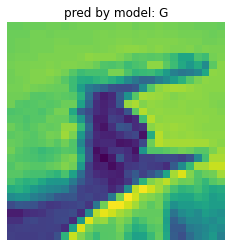

In [75]:
## Example pred

mini_pred = np.argmax(model.predict(X_test[0].reshape(1,28,28,1)),axis=-1)

plt.imshow(X_test[0].reshape(28,28))
plt.title(f'pred by model: {class_names[mini_pred[0]]}')
plt.axis('off')
plt.show()